# Olist E-Commerce Analysis
**Customer Loyalty · Revenue Opportunity · Geographic Coverage · Seller Health**

All queries run against dbt-built mart tables in BigQuery.  
All queries run against `olist_transformed_marts` in BigQuery.

In [64]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Configuration ────────────────────────────────────────────────────────
KEY_FILE = '/Users/tess/NTU/M2/Project/olist-498903-e7f8763e517a.json'
PROJECT  = 'olist-498903'
DATASET  = 'olist_transformed'

MARTS     = f'{PROJECT}.{DATASET}_marts'
STAGING   = f'{PROJECT}.{DATASET}_staging'
SNAPSHOTS = f'{PROJECT}.{DATASET}_snapshots'

client = bigquery.Client.from_service_account_json(KEY_FILE)

def q(sql: str) -> pd.DataFrame:
    return client.query(sql).to_dataframe()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.size']        = 16
plt.rcParams['axes.titlesize']   = 24
plt.rcParams['figure.titlesize'] = 28
plt.rcParams['axes.labelsize']   = 18
plt.rcParams['xtick.labelsize']  = 15
plt.rcParams['ytick.labelsize']  = 15
plt.rcParams['legend.fontsize']  = 16
plt.rcParams['axes.titlepad']    = 20

## 0. Known Data Quality Issues

Sourced from Great Expectations raw-layer validation (run 2026-06-13). Issues are handled either via explicit exclusion in queries below, inline query filters, or documented as context.

### Excluded from queries (`EXCL_SQL`)
| order_id | Issue |
|---|---|
| `bfbd0f9bdef84302105ad712db648a6c` | Delivered order with no payment record — `total_payment_value` NULL. Marts COALESCE to 0; excluded from raw queries. |

### Handled via inline query filters
| Issue | Count | Filter applied |
|---|---|---|
| Delivered orders missing delivery timestamp | 8 | `delivery_days IS NOT NULL` (Point 3) |
| Review creation date before order purchase date | 74 | `DATE(fr.review_creation_date) >= DATE(fo.order_purchase_timestamp)` (Point 4) |
| Products with NULL category name | 610 (~1.9%) | `dp.product_category_name_english IS NOT NULL` (Points 1 & 2) |

### Documented — retained in data
| Issue | Count | Severity | Notes |
|---|---|---|---|
| Zero or negative `payment_value` rows | 9 | Low | Revenue queries use `fo.price`, not `payment_value` — no direct impact |
| Payment > R$5,000 (potential fraud) | 6 | Low | Retained; flagged for fraud review |
| Installments > 12 | 185 | Medium | Outside Brazil norm; retained for analysis |
| Orders with > 5 payment methods | 118 | Medium | Unusual but valid |
| Payment vs item price mismatch > R$1 | 249 | Medium | Expected — installment interest and vouchers cause legitimate differences |
| Orders with multiple distinct reviews | 547 | Medium | Handled by composite key `(review_id, order_id)` in `fact_reviews` |
| Sellers with only 1 delivered order | 571 | Medium | Health score unreliable; shown in Point 4 distribution chart |
| Customer zip codes missing from geolocation | 7,824 | High | NULL lat/lng — does not affect state-level analysis in Point 3 |
| Seller zip codes missing from geolocation | 733 | Medium | NULL lat/lng for those sellers in `dim_sellers` |
| `customer_unique_id` with multiple `customer_id`s | 3,345 | High | Expected Olist design — all analysis uses `customer_unique_id` |

In [65]:
EXCLUDED_ORDERS = ['bfbd0f9bdef84302105ad712db648a6c']
EXCL_SQL = "'" + "', '".join(EXCLUDED_ORDERS) + "'"
print(f"Excluding {len(EXCLUDED_ORDERS)} order(s): {EXCLUDED_ORDERS}")

Excluding 1 order(s): ['bfbd0f9bdef84302105ad712db648a6c']


---
## 1. Customer Loyalty & Churn: The Category Effect

**Hypothesis tested:** Why do ~97% of customers never return?  
We tested 7 factors — geography, seller quality, product category, first-order spend, review score, payment method, and seasonality.

**Finding:** None of the "bad experience" factors predict churn. The real driver is **product category**.  
Durable goods (electronics, appliances) are naturally one-time purchases. Consumables and fashion have genuine repeat potential.

**Method:** For each customer, identify their first-order category, then check whether they placed a second order on the platform.

In [66]:
df_churn = q(f"""
WITH first_category AS (
    SELECT
        dc.customer_unique_id,
        dp.product_category_name_english AS first_category
    FROM `{MARTS}.fact_orders` fo
    JOIN `{MARTS}.dim_customers` dc ON fo.customer_id  = dc.customer_id
    JOIN `{MARTS}.dim_products`  dp ON fo.product_id   = dp.product_id
    WHERE fo.order_status = 'delivered'
      AND fo.order_id NOT IN ({EXCL_SQL})
      AND dp.product_category_name_english IS NOT NULL
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY dc.customer_unique_id
        ORDER BY fo.order_purchase_timestamp
    ) = 1
)
SELECT
    fc.first_category                              AS category,
    COUNT(*)                                       AS cohort_size,
    COUNTIF(mcs.total_orders > 1)                 AS returned,
    ROUND(COUNTIF(mcs.total_orders > 1)
          / COUNT(*) * 100, 1)                    AS return_rate_pct
FROM first_category fc
JOIN `{MARTS}.mart_customer_summary` mcs
    ON fc.customer_unique_id = mcs.customer_unique_id
GROUP BY category
HAVING cohort_size >= 50
ORDER BY return_rate_pct DESC
""")
df_churn.head(10)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,category,cohort_size,returned,return_rate_pct
0,home_appliances,676,60,8.9
1,furniture_bedroom,82,5,6.1
2,fashion_male_clothing,100,6,6.0
3,fashion_bags_accessories,1700,100,5.9
4,fashion_shoes,226,11,4.9
5,air_conditioning,235,11,4.7
6,furniture_living_room,389,18,4.6
7,furniture_decor,5928,274,4.6
8,bed_bath_table,8732,391,4.5
9,fashion_underwear_beach,114,5,4.4


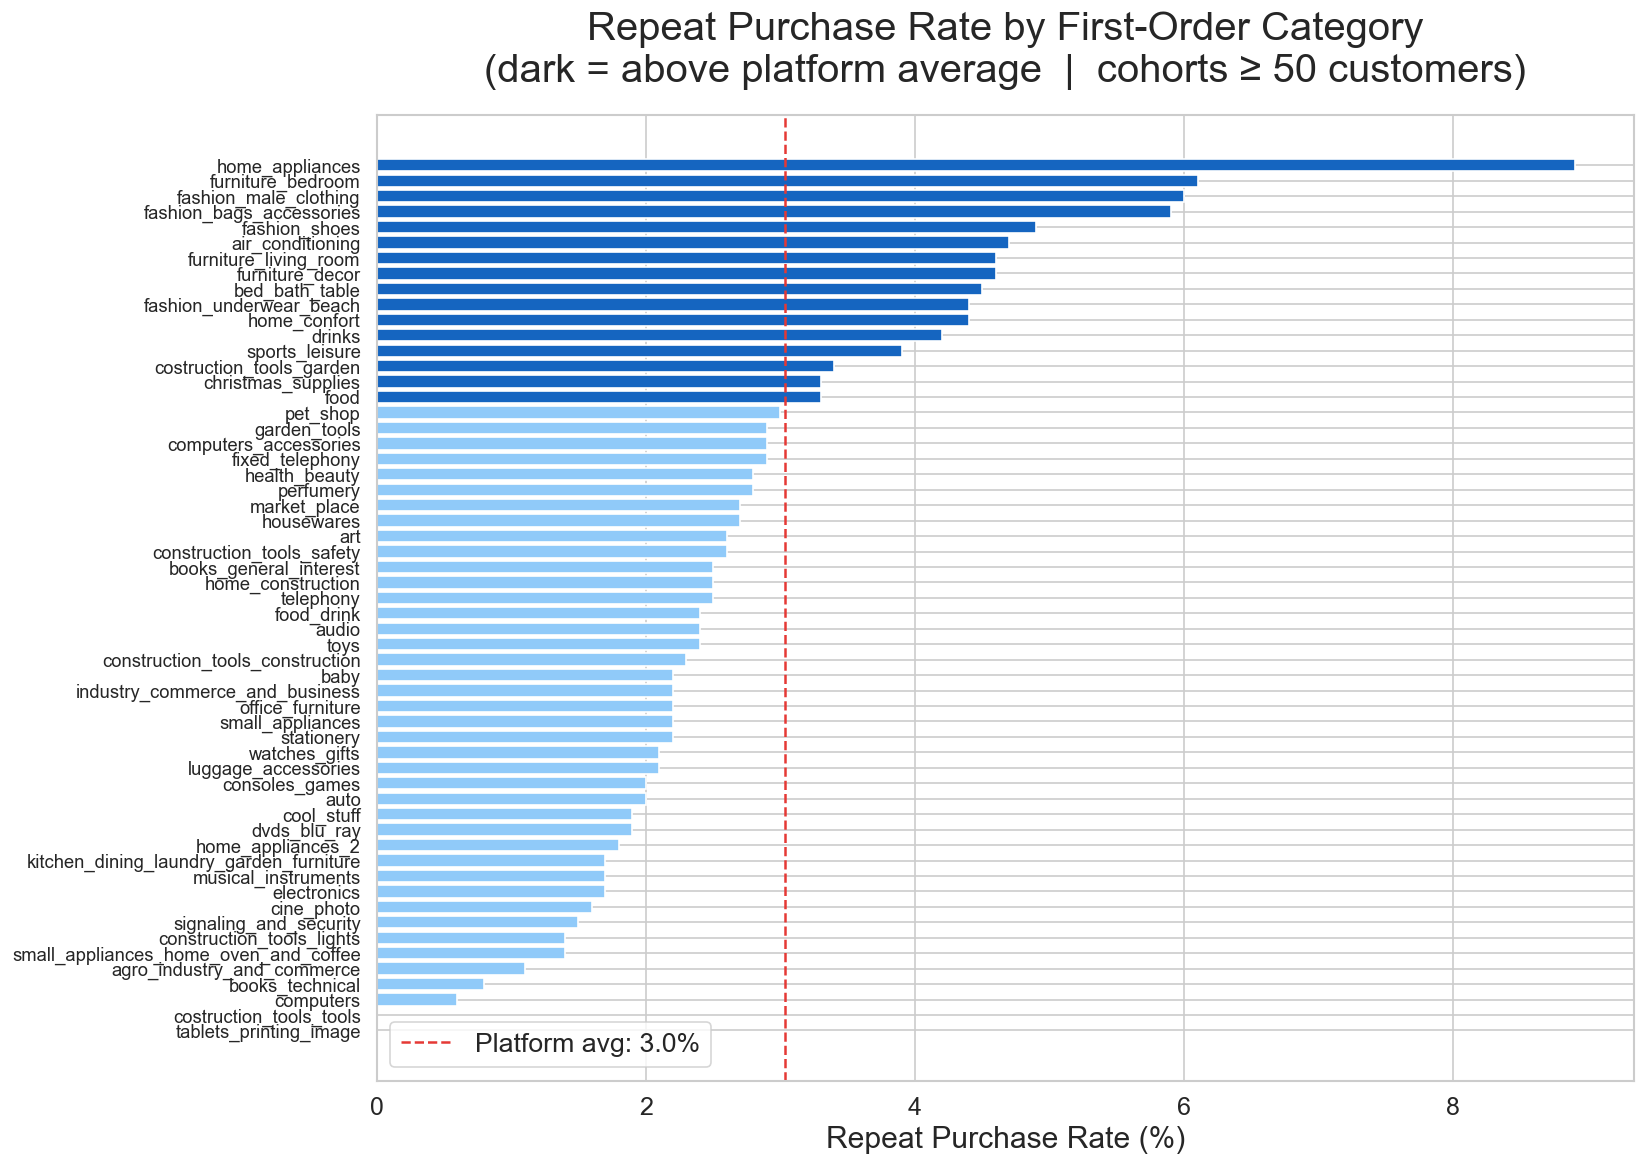

In [67]:
overall_rate = df_churn['returned'].sum() / df_churn['cohort_size'].sum() * 100

fig, ax = plt.subplots(figsize=(14, 10))
ax.tick_params(axis="y", labelsize=11)  # smaller labels so all categories fit one page
colors = ['#1565C0' if r > overall_rate else '#90CAF9'
          for r in df_churn['return_rate_pct']]
ax.barh(df_churn['category'], df_churn['return_rate_pct'], color=colors)
ax.axvline(overall_rate, color="#E53935", linestyle="--", linewidth=1.5,
           label=f"Platform avg: {overall_rate:.1f}%")
ax.set_xlabel("Repeat Purchase Rate (%)")
ax.set_title(
    "Repeat Purchase Rate by First-Order Category\n"
    "(dark = above platform average  |  cohorts ≥ 50 customers)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Revenue Opportunity Map: High-Revenue, Low-Churn Categories

**Finding:** Overlaying revenue and repeat rate reveals the platform's growth opportunity.  
Categories in the **top-right quadrant** (high revenue + above-average repeat rate) are where retention investment should be prioritised.

In [68]:
df_revenue = q(f"""
SELECT
    dp.product_category_name_english  AS category,
    COUNT(DISTINCT fo.order_id)        AS order_count,
    ROUND(SUM(fo.price), 0)            AS total_revenue
FROM `{MARTS}.fact_orders` fo
JOIN `{MARTS}.dim_products` dp ON fo.product_id = dp.product_id
WHERE fo.order_status = 'delivered'
  AND fo.order_id NOT IN ({EXCL_SQL})
  AND dp.product_category_name_english IS NOT NULL
GROUP BY category
ORDER BY total_revenue DESC
""")

df_opp = df_revenue.merge(df_churn[['category', 'return_rate_pct', 'cohort_size']],
                          on='category', how='inner')
df_opp.head(10)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,category,order_count,total_revenue,return_rate_pct,cohort_size
0,health_beauty,8646,1232997.000000000,2.8,8363
1,watches_gifts,5495,1166177.000000000,2.1,5320
2,bed_bath_table,9272,1023435.000000000,4.5,8732
3,sports_leisure,7530,954853.000000000,3.9,7209
4,computers_accessories,6530,888725.000000000,2.9,6296
5,furniture_decor,6307,711928.000000000,4.6,5928
6,housewares,5743,615629.000000000,2.7,5508
7,cool_stuff,3559,610204.000000000,1.9,3470
8,auto,3810,578967.000000000,2.0,3705
9,toys,3804,471286.000000000,2.4,3676


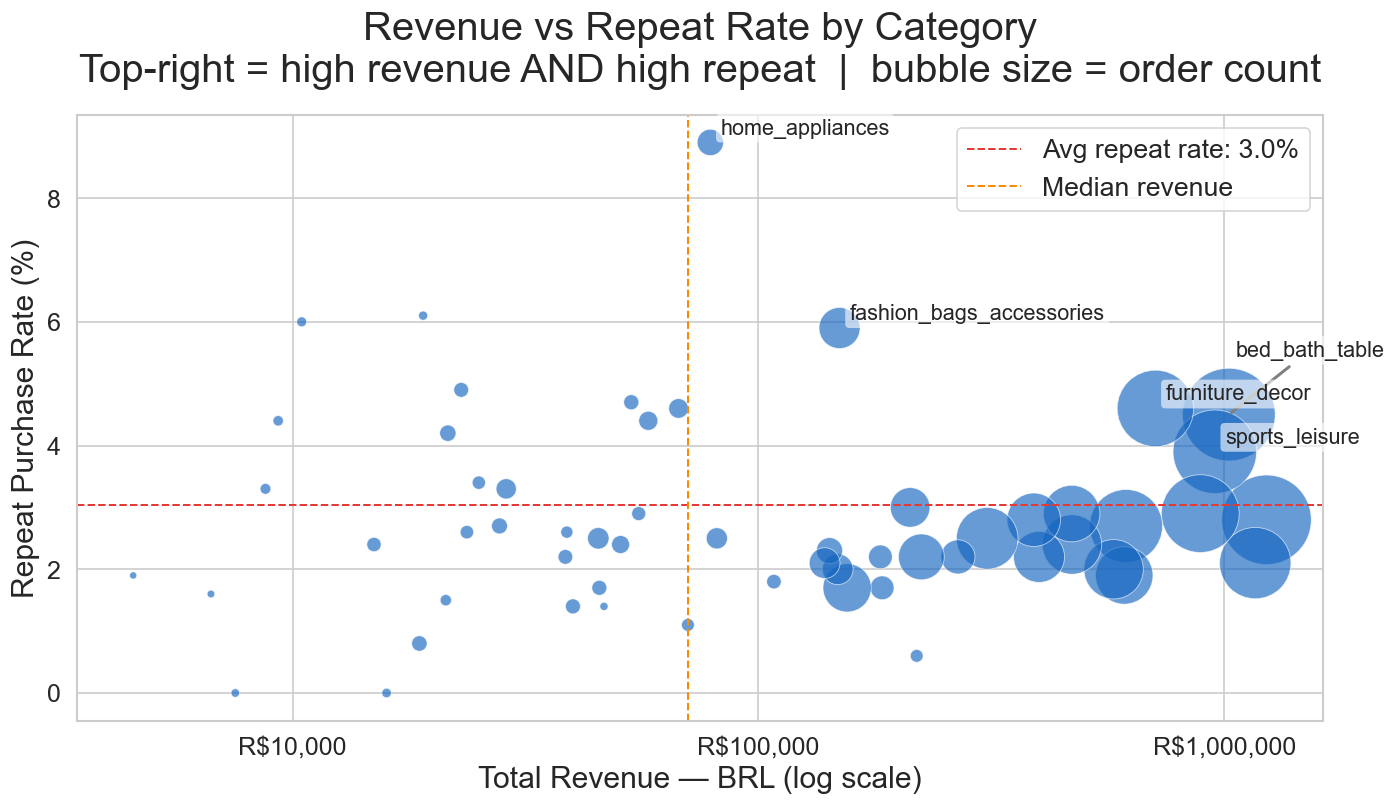

In [69]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(df_opp['total_revenue'], df_opp['return_rate_pct'],
           s=df_opp['order_count'] / 3, alpha=0.65, color='#1565C0',
           edgecolors='white', linewidths=0.5)

median_revenue = df_opp['total_revenue'].median()
ax.axhline(overall_rate, color="#E53935", linestyle="--", linewidth=1.2,
           label=f"Avg repeat rate: {overall_rate:.1f}%")
ax.axvline(median_revenue, color="#FB8C00", linestyle="--", linewidth=1.2,
           label="Median revenue")

top_right = df_opp[
    (df_opp['total_revenue'] > median_revenue) &
    (df_opp['return_rate_pct'] > overall_rate)
]
for _, row in top_right.iterrows():
    cat = row["category"]
    if cat == "bed_bath_table":
        offset, arrow = (4, 35), dict(arrowstyle="-", color="grey", lw=1.8)
    else:
        offset, arrow = (6, 5), None
    ax.annotate(cat, (row["total_revenue"], row["return_rate_pct"]),
                fontsize=13, xytext=offset, textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6),
                arrowprops=arrow)

ax.set_xscale("log")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}")
)
ax.set_xlabel("Total Revenue — BRL (log scale)")
ax.set_ylabel("Repeat Purchase Rate (%)")
ax.set_title("Revenue vs Repeat Rate by Category\n"
             "Top-right = high revenue AND high repeat  |  bubble size = order count")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Geographic Seller Concentration

**Finding:** Many Brazilian states outside São Paulo are severely underserved — high customer-to-seller ratios, slower delivery, and higher freight costs.  
Recruiting local sellers in these states would reduce logistics costs and delivery time, directly improving buyer experience and repeat purchase potential.

In [70]:
df_geo = q(f"""
WITH customer_counts AS (
    SELECT state, COUNT(DISTINCT customer_unique_id) AS customers
    FROM `{MARTS}.dim_customers`
    GROUP BY state
),
seller_counts AS (
    SELECT state, COUNT(DISTINCT seller_id) AS sellers
    FROM `{MARTS}.dim_sellers`
    GROUP BY state
),
delivery_stats AS (
    SELECT
        dc.state,
        ROUND(AVG(fo.delivery_days), 1) AS avg_delivery_days,
        ROUND(AVG(fo.freight_value), 2) AS avg_freight
    FROM `{MARTS}.fact_orders` fo
    JOIN `{MARTS}.dim_customers` dc ON fo.customer_id = dc.customer_id
    WHERE fo.order_status = 'delivered'
      AND fo.delivery_days IS NOT NULL
      AND fo.order_id NOT IN ({EXCL_SQL})
    GROUP BY dc.state
)
SELECT
    c.state,
    c.customers,
    COALESCE(s.sellers, 0)                                     AS sellers,
    ROUND(c.customers / NULLIF(COALESCE(s.sellers, 0), 0), 0) AS customer_per_seller,
    d.avg_delivery_days,
    d.avg_freight
FROM customer_counts   c
LEFT JOIN seller_counts  s ON c.state = s.state
LEFT JOIN delivery_stats d ON c.state = d.state
WHERE c.customers >= 100
ORDER BY customer_per_seller DESC
""")
df_geo.head(10)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,state,customers,sellers,customer_per_seller,avg_delivery_days,avg_freight
0,PA,949,1,949.0,23.3,35.630000000
1,MA,726,1,726.0,21.2,38.490000000
2,PI,482,1,482.0,18.9,39.120000000
3,MT,876,4,219.0,17.5,28.000000000
4,PE,1609,9,179.0,17.8,32.690000000
5,BA,3277,19,172.0,18.8,26.490000000
6,SE,342,2,171.0,21.0,36.570000000
7,AM,143,1,143.0,26.0,33.310000000
8,MS,694,5,139.0,15.1,23.350000000
9,RO,240,2,120.0,19.3,41.330000000


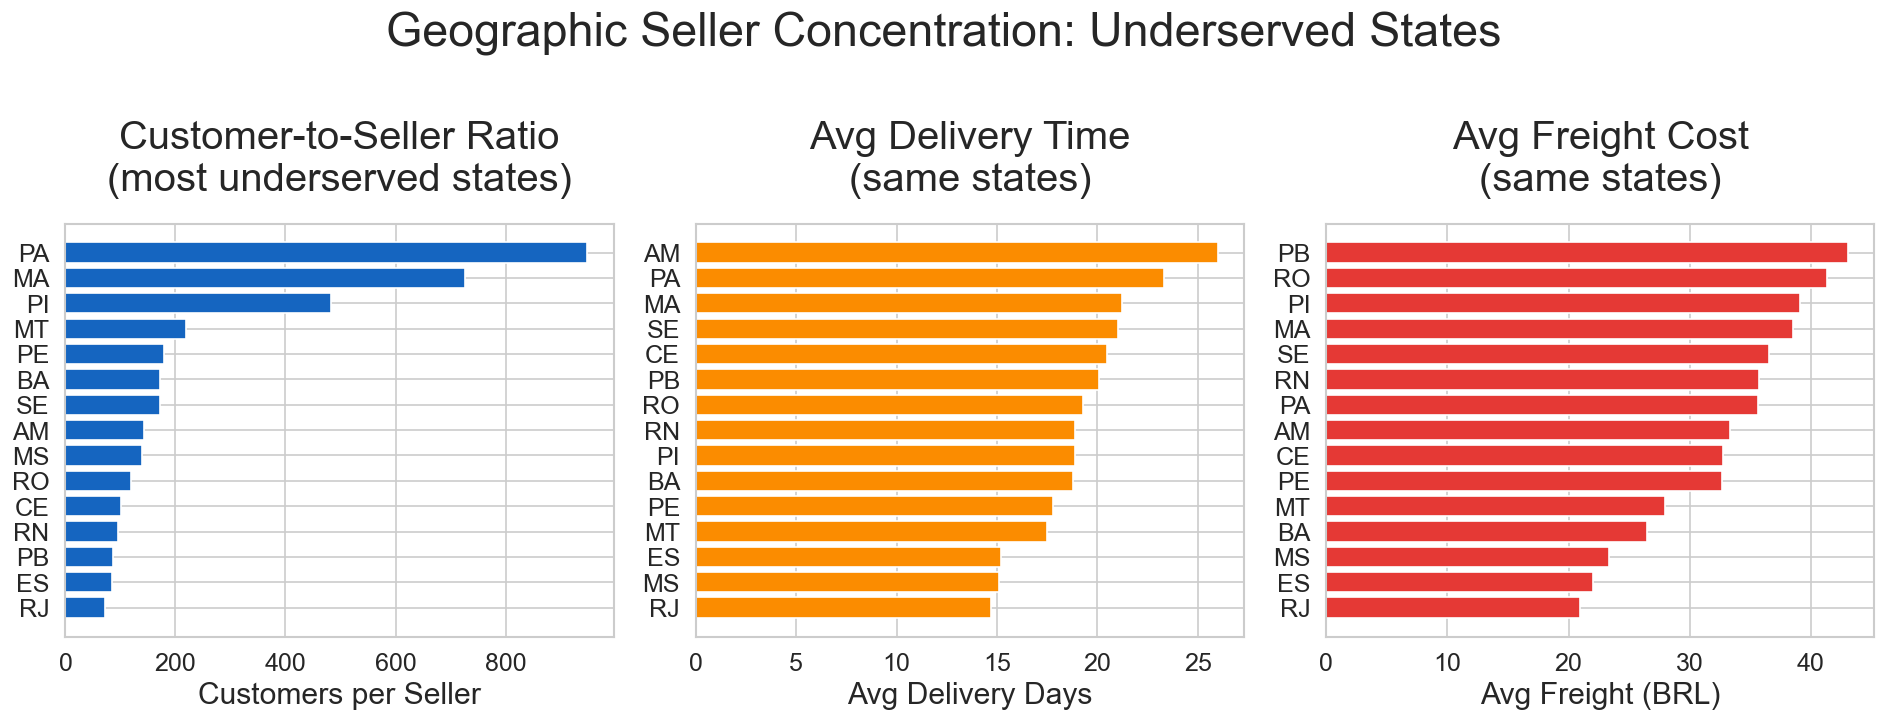

In [71]:
df_top = df_geo.sort_values('customer_per_seller', ascending=False).head(15)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

df_ratio = df_top.sort_values('customer_per_seller')
axes[0].barh(df_ratio['state'], df_ratio['customer_per_seller'], color='#1565C0')
axes[0].set_xlabel("Customers per Seller")
axes[0].set_title("Customer-to-Seller Ratio\n(most underserved states)")

df_del = df_top.sort_values('avg_delivery_days')
axes[1].barh(df_del['state'], df_del['avg_delivery_days'], color='#FB8C00')
axes[1].set_xlabel("Avg Delivery Days")
axes[1].set_title("Avg Delivery Time\n(same states)")

df_frg = df_top.sort_values('avg_freight')
axes[2].barh(df_frg['state'], df_frg['avg_freight'], color='#E53935')
axes[2].set_xlabel("Avg Freight (BRL)")
axes[2].set_title("Avg Freight Cost\n(same states)")

plt.suptitle("Geographic Seller Concentration: Underserved States", y=1.01)
plt.tight_layout()
plt.show()

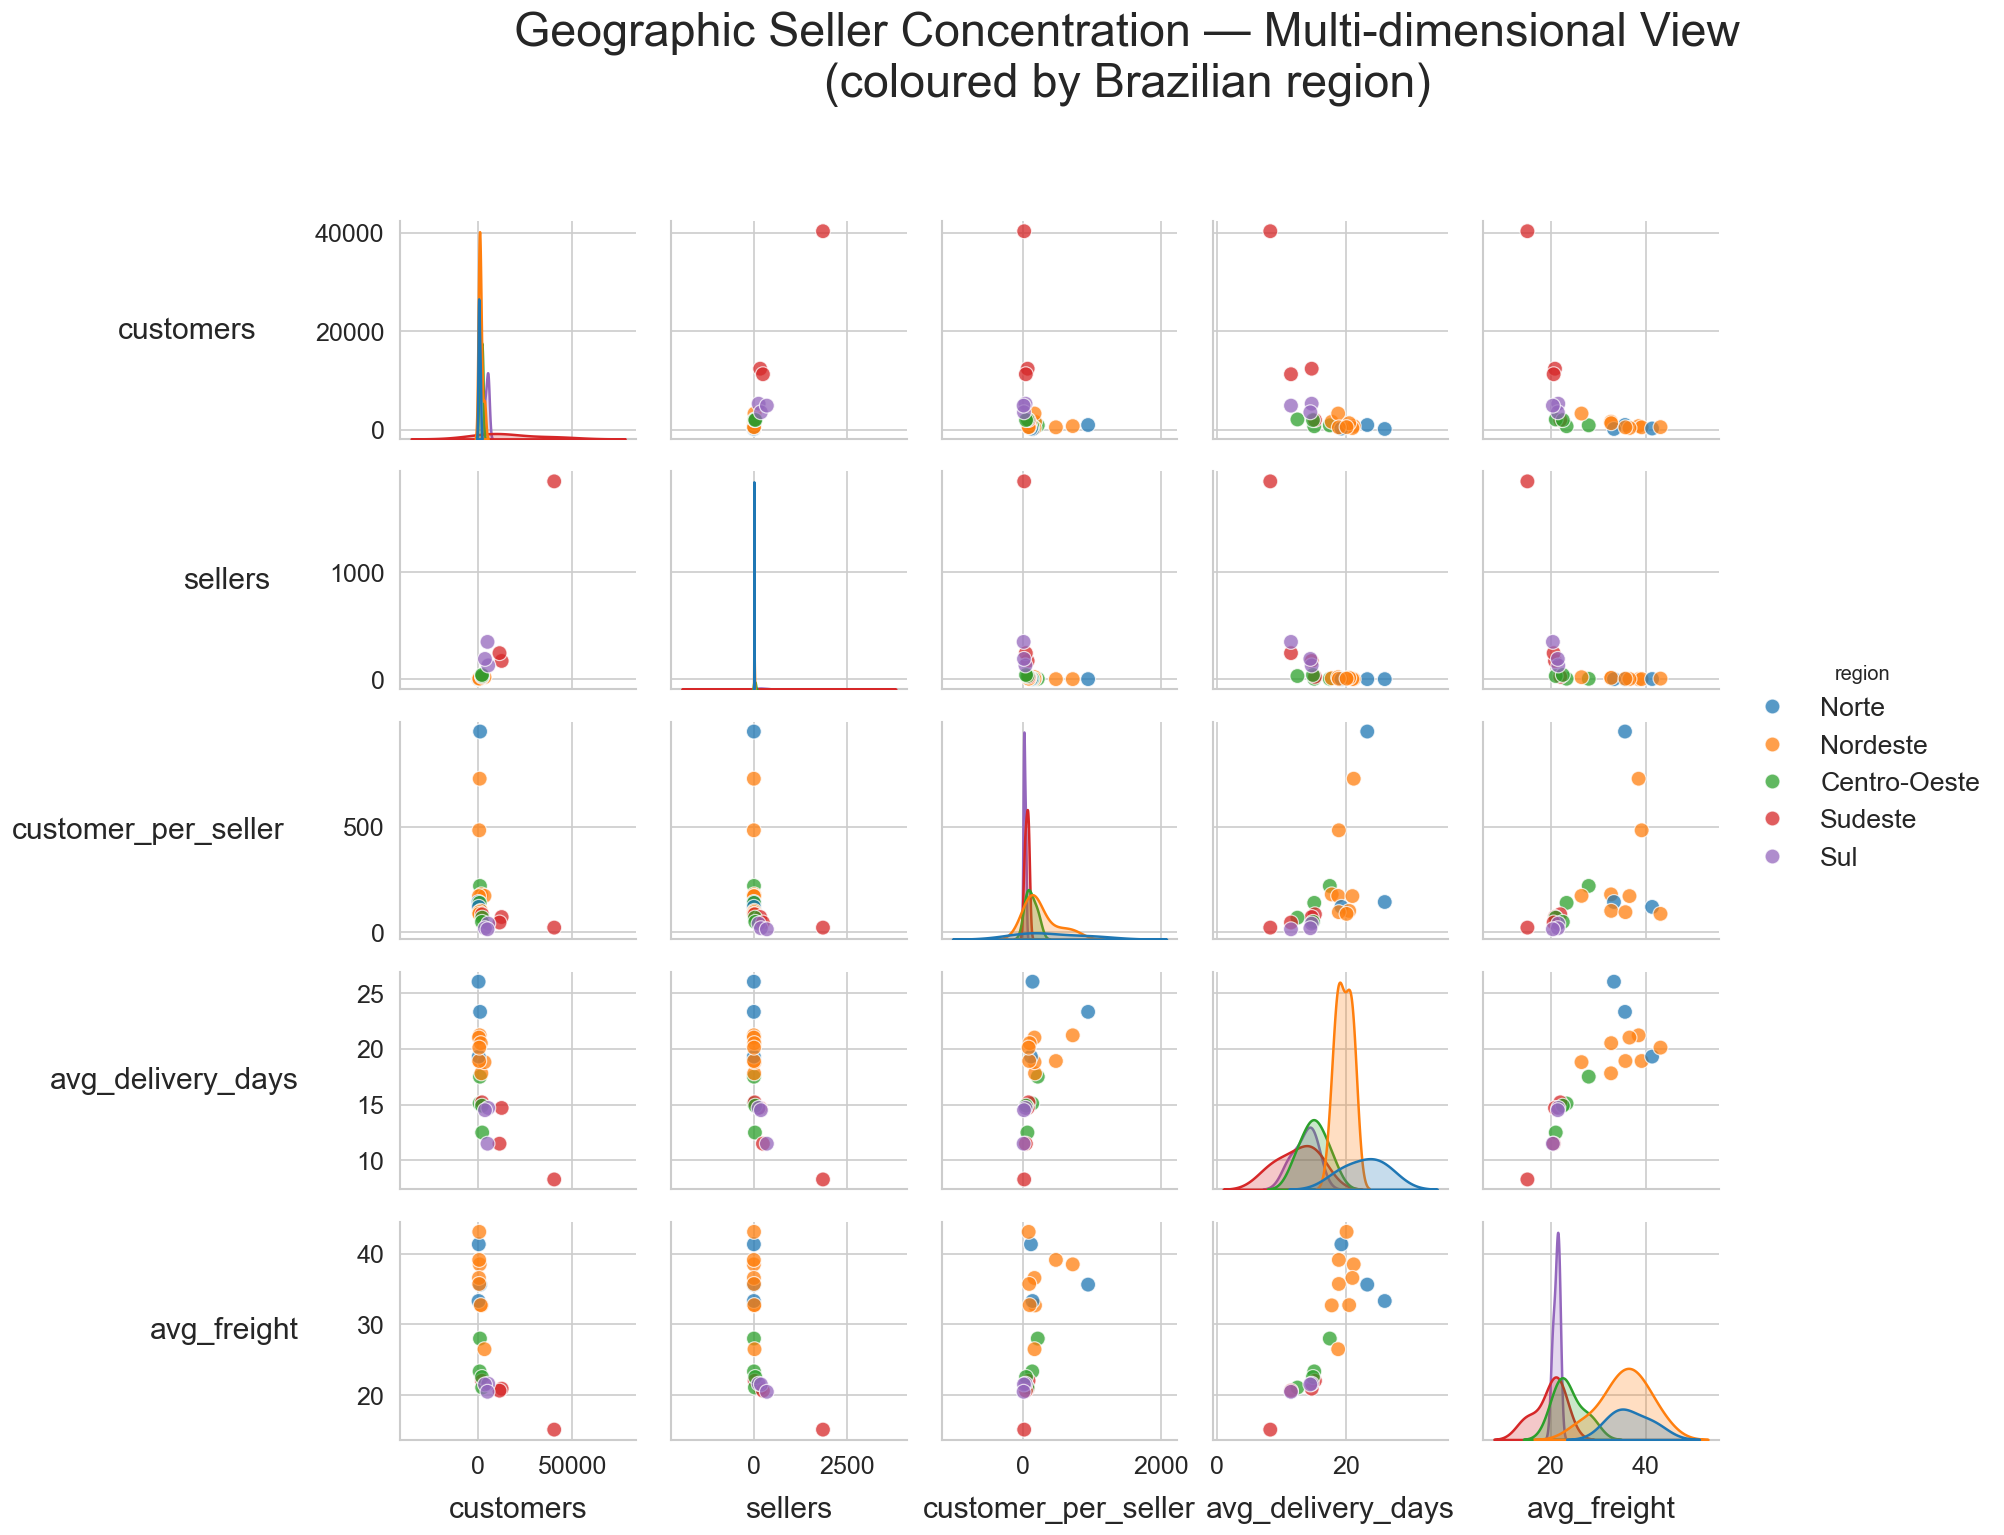

In [72]:
# Map Brazilian states to regions for colour coding
REGION_MAP = {
    'AM': 'Norte',  'PA': 'Norte',  'AC': 'Norte',  'RO': 'Norte',
    'RR': 'Norte',  'AP': 'Norte',  'TO': 'Norte',
    'MA': 'Nordeste', 'PI': 'Nordeste', 'CE': 'Nordeste', 'RN': 'Nordeste',
    'PB': 'Nordeste', 'PE': 'Nordeste', 'AL': 'Nordeste', 'SE': 'Nordeste', 'BA': 'Nordeste',
    'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'DF': 'Centro-Oeste',
    'SP': 'Sudeste',  'RJ': 'Sudeste',  'MG': 'Sudeste',  'ES': 'Sudeste',
    'PR': 'Sul',      'SC': 'Sul',      'RS': 'Sul'
}
df_geo['region'] = df_geo['state'].map(REGION_MAP)

pair_cols = ['customers', 'sellers', 'customer_per_seller',
             'avg_delivery_days', 'avg_freight']

g = sns.pairplot(
    df_geo[pair_cols + ['region']].dropna(),
    hue='region',
    palette='tab10',
    diag_kind='kde',
    plot_kws={'alpha': 0.75, 's': 80},
    diag_kws={'linewidth': 1.5}
)
g.figure.suptitle(
    'Geographic Seller Concentration — Multi-dimensional View\n'
    '(coloured by Brazilian region)',
    y=1.02
)
# moderate spacing between subplots + room for suptitle
g.figure.subplots_adjust(top=0.88, hspace=0.15, wspace=0.15)
# horizontal y-axis labels with padding so they clear the tick marks
for ax in g.axes.flatten():
    if ax is not None:
        ax.yaxis.label.set_rotation(0)
        ax.yaxis.label.set_ha("right")
        ax.yaxis.label.set_va("center")
        ax.yaxis.labelpad = 35
        ax.xaxis.labelpad = 10
plt.show()

### 3b. Focused View — The Logistics Penalty of Under-Supply

The pairplot above captures all pairwise relationships for exploration. This panel isolates the **primary argument**: states with fewer sellers per customer pay more *and* wait longer for their orders.

A positive trend line in both panels confirms the pattern. **Norte and Nordeste** states cluster toward the top-right — they are the priority targets for seller recruitment. Closing the supply gap there would reduce freight costs and delivery times, directly improving customer experience and repeat rates in the regions Olist currently serves least well.

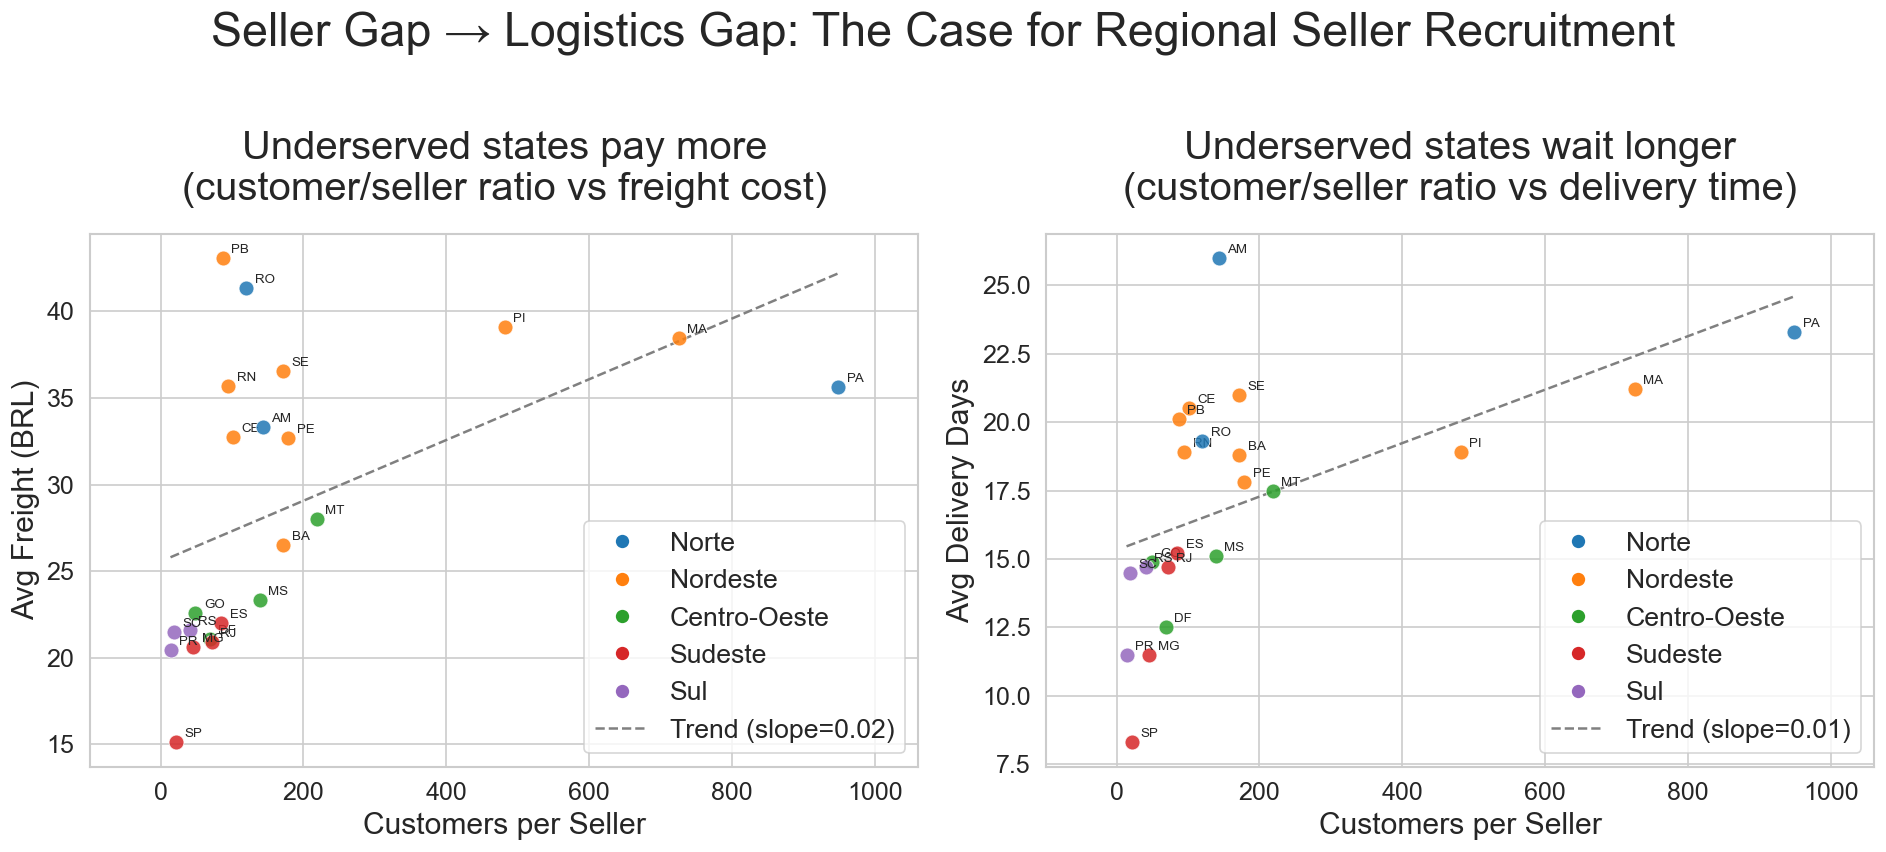

In [73]:
import numpy as np
from matplotlib.lines import Line2D

_region_order = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
_p3b_pal = dict(zip(_region_order, sns.color_palette("tab10", len(_region_order))))

df_s = df_geo.dropna(subset=['customer_per_seller', 'avg_freight', 'avg_delivery_days', 'region'])

def _p3b_panel(ax, y_col, y_label):
    for region, grp in df_s.groupby("region"):
        ax.scatter(grp["customer_per_seller"], grp[y_col],
                   color=_p3b_pal[region], s=80, alpha=0.85,
                   edgecolors="white", linewidths=0.5, zorder=3)
        for _, row in grp.iterrows():
            ax.annotate(row["state"],
                        (row["customer_per_seller"], row[y_col]),
                        fontsize=8, xytext=(5, 3), textcoords="offset points")
    x = df_s["customer_per_seller"].astype(float).values
    y = df_s[y_col].astype(float).values
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color="grey", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Customers per Seller")
    ax.set_ylabel(y_label)
    ax.margins(x=0.12)
    handles = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=_p3b_pal[r], markeredgecolor="white",
               markersize=9, label=r)
        for r in _region_order if r in df_s["region"].values
    ]
    handles.append(Line2D([0], [0], color="grey", linestyle="--",
                          linewidth=1.5, label=f"Trend (slope={m:.2f})"))
    ax.legend(handles=handles, loc="lower right")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_p3b_panel(axes[0], "avg_freight",       "Avg Freight (BRL)")
axes[0].set_title("Underserved states pay more\n(customer/seller ratio vs freight cost)")

_p3b_panel(axes[1], "avg_delivery_days", "Avg Delivery Days")
axes[1].set_title("Underserved states wait longer\n(customer/seller ratio vs delivery time)")

plt.suptitle(
    "Seller Gap → Logistics Gap: The Case for Regional Seller Recruitment",
    y=1.02
)
plt.tight_layout()
plt.show()

---
## 4. Seller Health Monitoring

**Finding:** 18% of sellers made exactly one sale and disappeared. Olist currently has no mechanism to detect declining sellers before they churn, threatening supply diversity.

**Our pipeline's contribution:** `snap_dim_sellers` (SCD Type 2 snapshot on `stg_sellers`) gives Olist the infrastructure to track seller changes over time — including address changes that may correlate with shifts in delivery performance. Combined with the monthly health metrics below, this enables an early-warning system to intervene before a seller goes dark.

In [74]:
df_seller_dist = q(f"""
WITH seller_orders AS (
    SELECT seller_id, COUNT(DISTINCT order_id) AS order_count
    FROM `{MARTS}.fact_orders`
    WHERE order_status = 'delivered'
    GROUP BY seller_id
)
SELECT
    CASE
        WHEN order_count = 1              THEN '1 (one-and-done)'
        WHEN order_count BETWEEN 2 AND 5  THEN '2–5'
        WHEN order_count BETWEEN 6 AND 20 THEN '6–20'
        ELSE '21+'
    END                                                        AS sales_bucket,
    COUNT(*)                                                   AS seller_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1)        AS pct
FROM seller_orders
GROUP BY sales_bucket
ORDER BY MIN(order_count)
""")
print(df_seller_dist.to_string(index=False))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


    sales_bucket  seller_count  pct
1 (one-and-done)           535 18.0
             2–5           807 27.2
            6–20           843 28.4
             21+           785 26.4


In [75]:
df_monthly = q(f"""
SELECT
    DATE_TRUNC(DATE(fo.order_purchase_timestamp), MONTH) AS month,
    COUNT(DISTINCT fo.seller_id)                          AS active_sellers,
    ROUND(AVG(fr.review_score), 2)                        AS avg_review_score,
    ROUND(COUNTIF(fo.is_late) / COUNT(*) * 100, 1)        AS late_delivery_pct
FROM `{MARTS}.fact_orders` fo
LEFT JOIN `{MARTS}.fact_reviews` fr
    ON fo.order_id = fr.order_id
    AND DATE(fr.review_creation_date) >= DATE(fo.order_purchase_timestamp)  -- exclude 74 anomalous reviews
WHERE fo.order_status = 'delivered'
  AND fo.order_id NOT IN ({EXCL_SQL})
GROUP BY month
ORDER BY month
""")
df_monthly['month'] = pd.to_datetime(df_monthly['month'])
df_monthly.head()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,month,active_sellers,avg_review_score,late_delivery_pct
0,2016-10-01,128,3.91,0.9
1,2016-12-01,1,5.00,0.0
2,2017-01-01,219,4.17,2.8
3,2017-02-01,402,4.18,3.3
4,2017-03-01,476,4.13,5.6


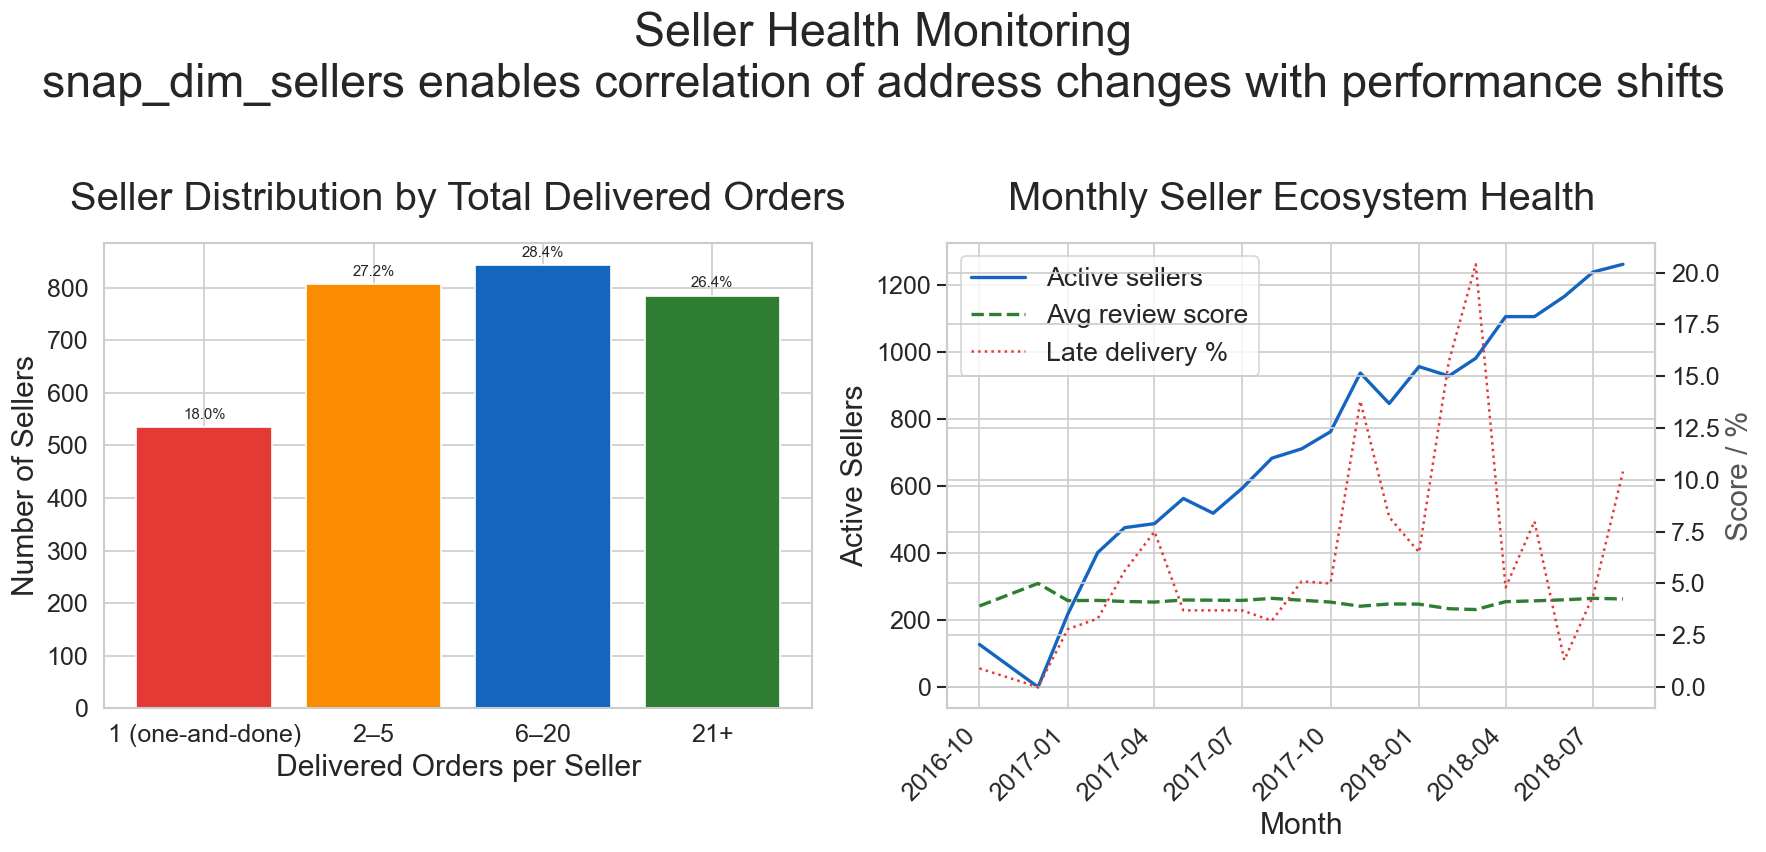

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

bar_colors = ['#E53935', '#FB8C00', '#1565C0', '#2E7D32']
bars = axes[0].bar(df_seller_dist['sales_bucket'],
                   df_seller_dist['seller_count'], color=bar_colors)
for bar, pct in zip(bars, df_seller_dist["pct"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 10,
                 f"{pct}%", ha="center", va="bottom", fontsize=9)
axes[0].set_xlabel("Delivered Orders per Seller")
axes[0].set_ylabel("Number of Sellers")
axes[0].set_title("Seller Distribution by Total Delivered Orders")

ax_r = axes[1].twinx()
axes[1].plot(df_monthly['month'], df_monthly['active_sellers'],
             color='#1565C0', linewidth=2, label='Active sellers')
ax_r.plot(df_monthly['month'], df_monthly['avg_review_score'],
          color='#2E7D32', linewidth=2, linestyle='--', label='Avg review score')
ax_r.plot(df_monthly['month'], df_monthly['late_delivery_pct'],
          color='#E53935', linewidth=1.5, linestyle=':', label='Late delivery %')

axes[1].set_xlabel("Month")
axes[1].set_ylabel("Active Sellers")
ax_r.set_ylabel("Score / %", color="#555")
axes[1].set_title("Monthly Seller Ecosystem Health")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right")

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.suptitle(
    "Seller Health Monitoring\n"
    "snap_dim_sellers enables correlation of address changes with performance shifts",
    y=1.02
)
plt.tight_layout()
plt.show()

---
## 5. Delivery Failure vs Customer Churn — Regional View

**Question:** Do late delivery or high freight cost on the first order predict whether a customer will return?  
**Method:** For each customer, capture their first delivered order's `is_late` flag and `freight_value`, then check if they ever returned (`total_orders > 1`). Aggregate by state and compare both factors against churn rate side-by-side.

**Interpretation:** A flat trend line (near-zero slope) in both charts would support Point 1's finding that bad experience factors do not drive churn — product category remains the dominant driver.  
Regional clustering reveals whether Norte/Nordeste states (high freight, slow delivery) show systematically different churn behaviour from Sudeste/Sul.

In [77]:
df_dc = q(f"""
WITH customer_first_order AS (
    SELECT
        dc.customer_unique_id,
        dc.state,
        fo.is_late,
        fo.freight_value,
        ROW_NUMBER() OVER (
            PARTITION BY dc.customer_unique_id
            ORDER BY fo.order_purchase_timestamp
        ) AS rn
    FROM `{MARTS}.fact_orders` fo
    JOIN `{MARTS}.dim_customers` dc ON fo.customer_id = dc.customer_id
    WHERE fo.order_status = 'delivered'
      AND fo.order_id NOT IN ({EXCL_SQL})
),
first_orders AS (
    SELECT customer_unique_id, state, is_late, freight_value
    FROM customer_first_order
    WHERE rn = 1
)
SELECT
    fo.state,
    COUNT(*)                                                    AS customers,
    ROUND(COUNTIF(fo.is_late) / COUNT(*) * 100, 1)             AS late_rate_pct,
    ROUND(AVG(fo.freight_value), 2)                            AS avg_freight_first_order,
    ROUND(COUNTIF(mcs.total_orders = 1) / COUNT(*) * 100, 1)   AS churn_rate_pct
FROM first_orders fo
JOIN `{MARTS}.mart_customer_summary` mcs
    ON fo.customer_unique_id = mcs.customer_unique_id
GROUP BY fo.state
HAVING COUNT(*) >= 100
ORDER BY late_rate_pct DESC
""")
df_dc['region'] = df_dc['state'].map(REGION_MAP)

region_order = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
p5_palette = dict(zip(region_order, sns.color_palette("tab10", len(region_order))))
df_dc

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,state,customers,late_rate_pct,avg_freight_first_order,churn_rate_pct,region
0,AL,387,24.0,36.150000000,97.4,Nordeste
1,MA,698,19.6,38.240000000,98.1,Nordeste
2,PI,464,16.2,39.060000000,97.8,Nordeste
3,CE,1257,15.5,33.200000000,98.4,Nordeste
4,SE,327,15.3,36.760000000,97.9,Nordeste
5,BA,3158,14.1,26.320000000,97.2,Nordeste
6,RJ,11913,13.5,21.120000000,96.7,Sudeste
7,TO,267,12.4,38.140000000,97.4,Norte
8,ES,1927,12.3,22.220000000,97.1,Sudeste
9,PA,922,12.1,36.170000000,97.6,Norte


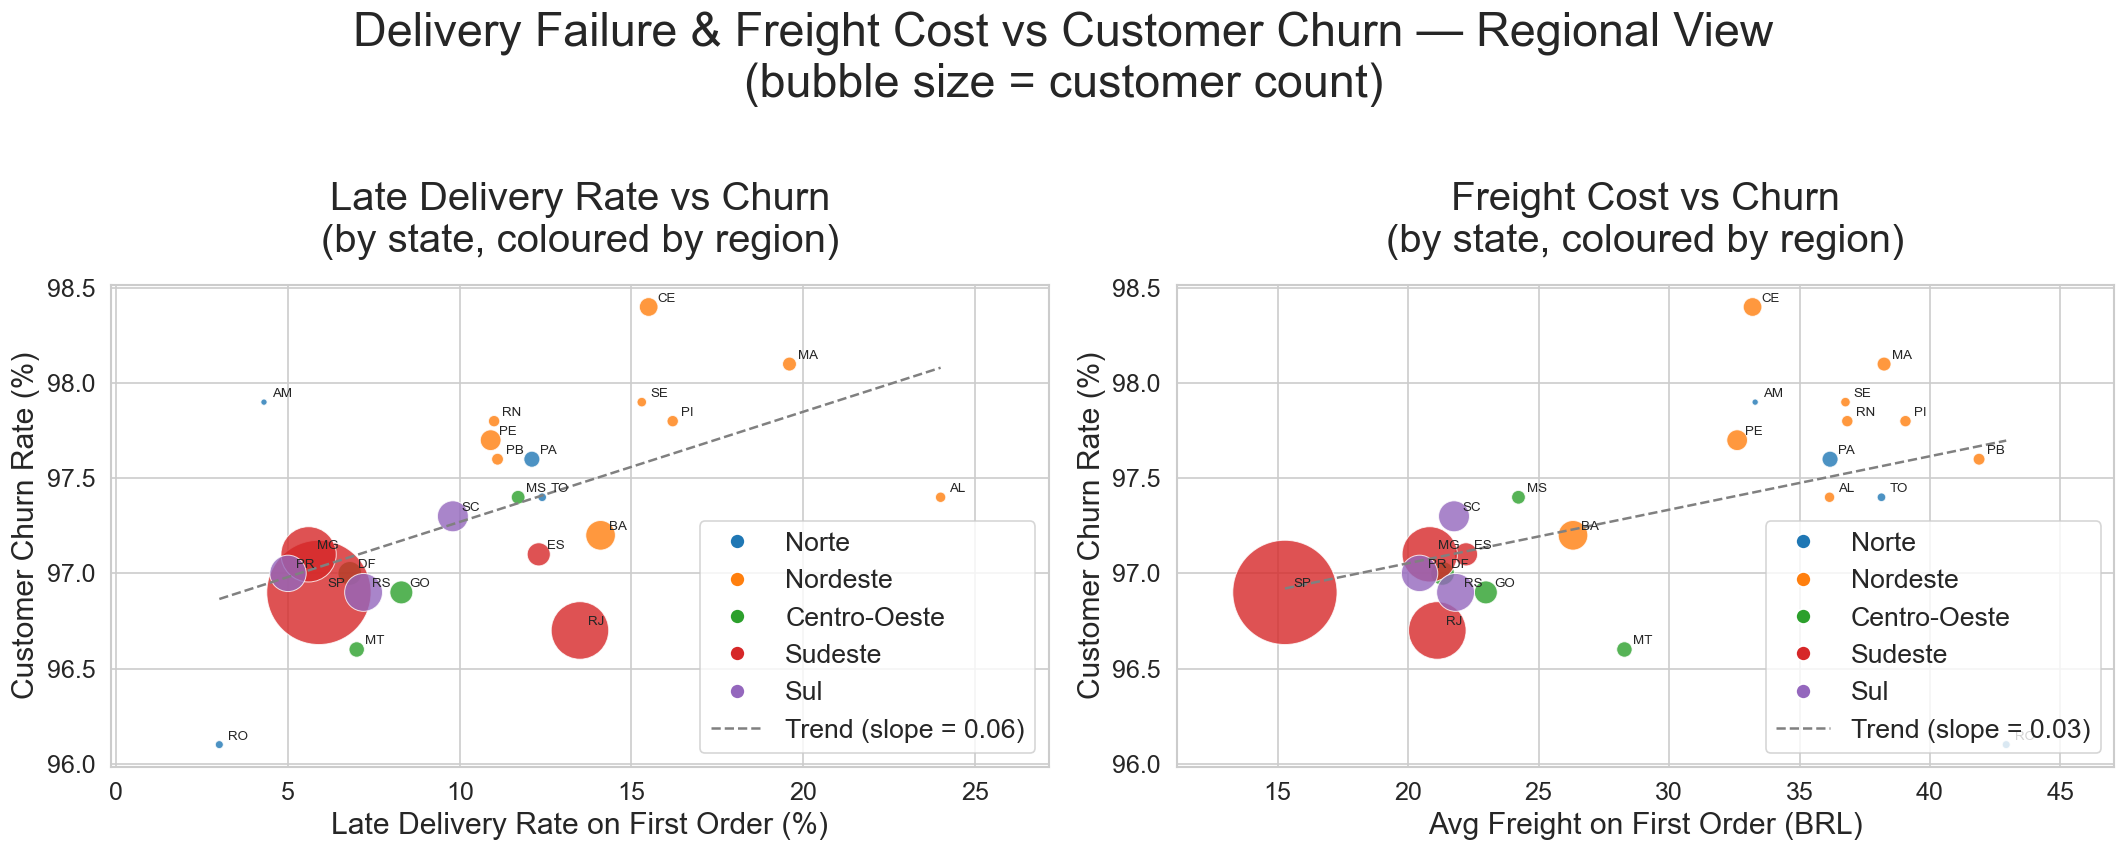

Late delivery rate: slope = 0.058  →  weak/no correlation with churn
Avg freight cost: slope = 0.028  →  weak/no correlation with churn


In [78]:
import numpy as np
from matplotlib.lines import Line2D

def scatter_churn(ax, x_col, x_label):
    for region, grp in df_dc.groupby("region"):
        ax.scatter(
            grp[x_col], grp["churn_rate_pct"],
            s=grp["customers"] / 10,
            color=p5_palette[region], alpha=0.8,
            edgecolors="white", linewidths=0.6
        )
        for _, row in grp.iterrows():
            ax.annotate(
                row["state"],
                (row[x_col], row["churn_rate_pct"]),
                fontsize=8, xytext=(5, 3), textcoords="offset points"
            )
    x = df_dc[x_col].astype(float).values
    y = df_dc["churn_rate_pct"].astype(float).values
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color="grey", linestyle="--", linewidth=1.5)
    # uniform-size legend handles
    handles = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=p5_palette[r], markeredgecolor="white",
               markersize=9, label=r)
        for r in region_order
    ]
    handles.append(Line2D([0], [0], color="grey", linestyle="--",
                           linewidth=1.5, label=f"Trend (slope = {m:.2f})"))
    ax.margins(x=0.15)
    ax.set_ylabel("Customer Churn Rate (%)")
    ax.set_xlabel(x_label)
    ax.legend(handles=handles, loc="lower right")
    return m

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

m_late = scatter_churn(axes[0], "late_rate_pct", "Late Delivery Rate on First Order (%)")
axes[0].set_title("Late Delivery Rate vs Churn\n(by state, coloured by region)")

m_freight = scatter_churn(axes[1], "avg_freight_first_order", "Avg Freight on First Order (BRL)")
axes[1].set_title("Freight Cost vs Churn\n(by state, coloured by region)")

plt.suptitle(
    "Delivery Failure & Freight Cost vs Customer Churn — Regional View\n"
    "(bubble size = customer count)",
    y=1.02
)
plt.tight_layout()
plt.show()

for label, m in [("Late delivery rate", m_late), ("Avg freight cost", m_freight)]:
    strength = "weak/no" if abs(m) < 0.1 else "meaningful"
    print(f"{label}: slope = {m:.3f}  →  {strength} correlation with churn")

---
## 6. Cohort Retention — When Buyers Disengage

**What this tells us:** Each row is a group of customers who made their first purchase in the same month (their cohort). Each column shows what percentage of that cohort placed another order N months later.  
Month 0 is always 100% — that's the acquisition month itself.

**Why it matters for campaigns:** The heatmap reveals the exact moment retention collapses. If month 2 drops sharply, that's the intervention window — a well-timed campaign at month 1–2 post-purchase could recover a significant share of the 97% who never return.

**Automation:** `mart_cohort_retention` refreshes with every `dbt run`. A Dagster job can email the updated heatmap to the marketing team on a weekly cadence.

In [79]:
df_cohort = q(f"""
SELECT cohort_month, months_since_first, retention_rate_pct
FROM `{MARTS}.mart_cohort_retention`
ORDER BY cohort_month, months_since_first
""")
df_cohort['cohort_month'] = pd.to_datetime(df_cohort['cohort_month']).dt.strftime('%Y-%m')
df_cohort.head(10)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,cohort_month,months_since_first,retention_rate_pct
0,2016-09,0,100.00
1,2016-10,0,100.00
2,2016-10,6,0.38
3,2016-10,9,0.38
4,2016-10,11,0.38
5,2016-10,13,0.38
6,2016-10,15,0.38
7,2016-10,17,0.38
8,2016-10,19,0.76
9,2016-10,20,0.76


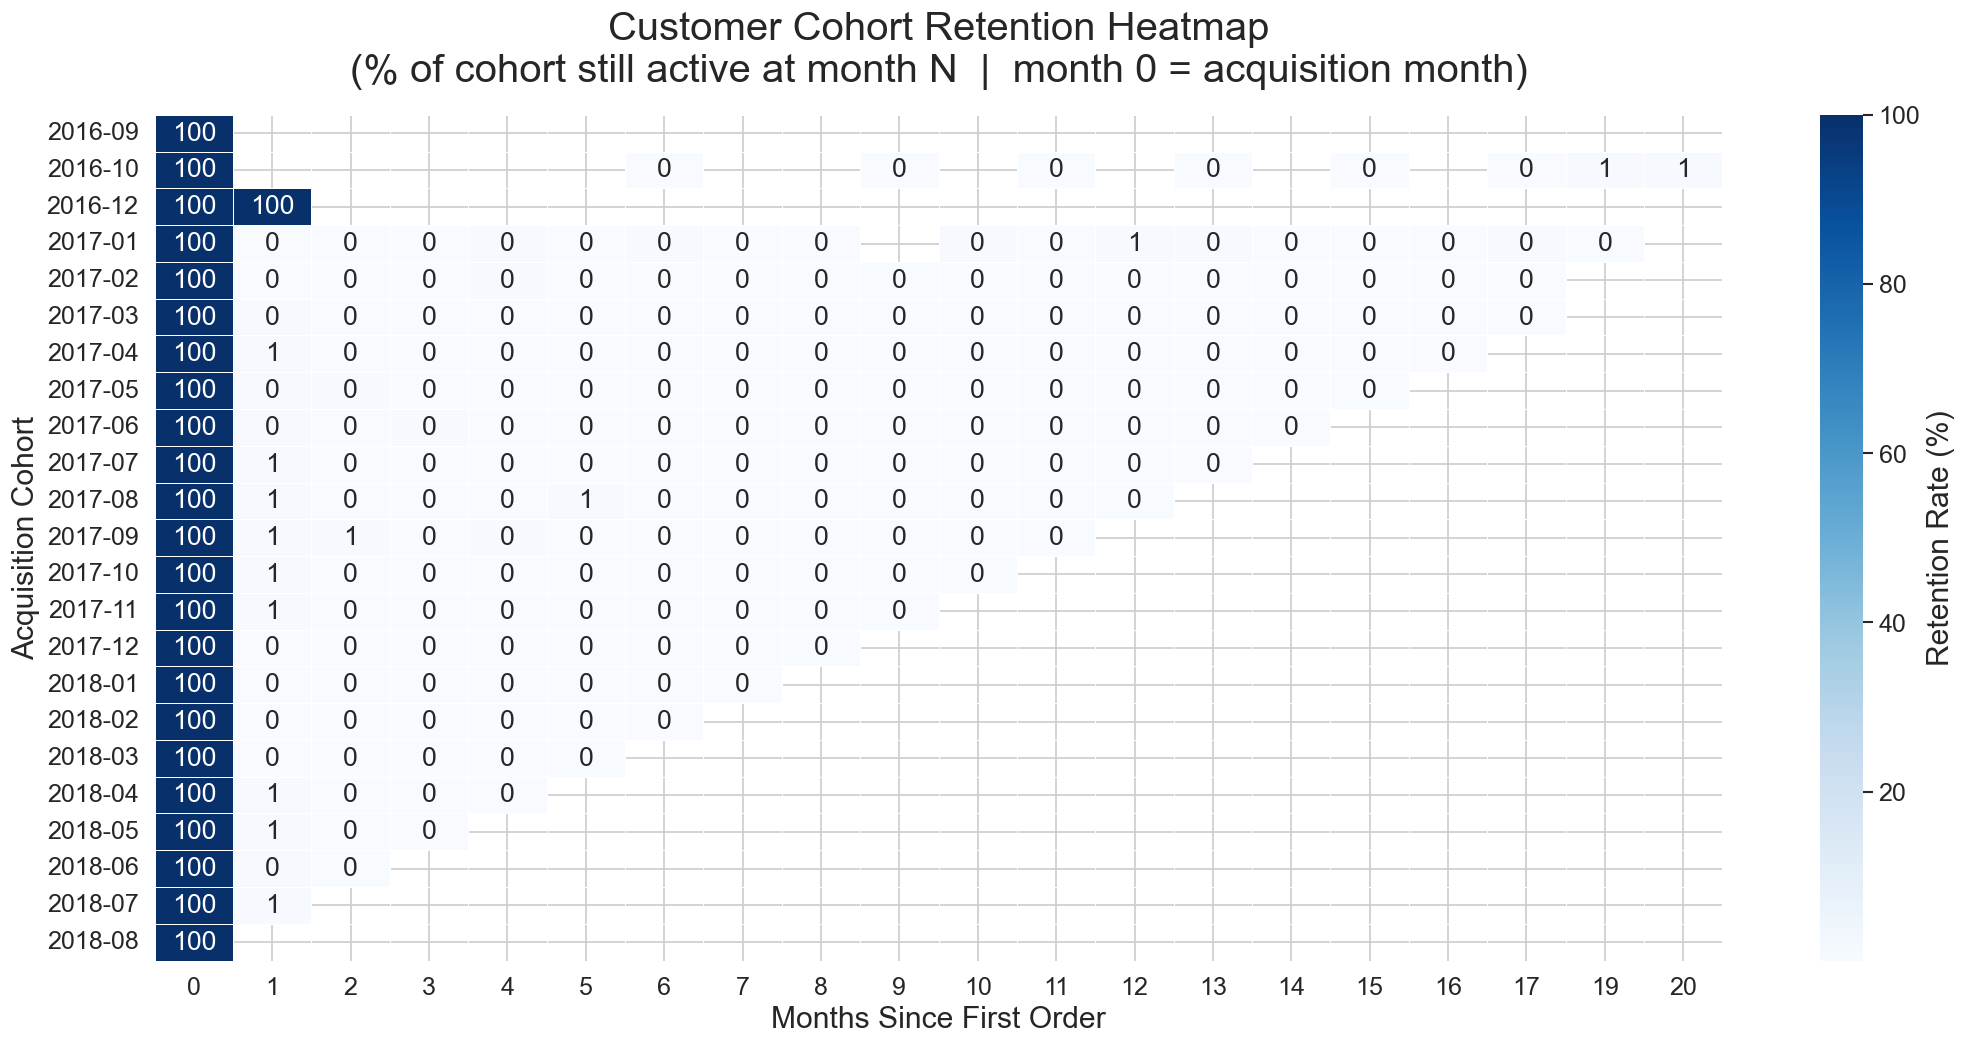

Avg retention  month 1: 5.5%
Avg retention  month 2: 0.3%
Drop month 1→2: 5.1 pp — primary campaign intervention window


In [80]:
pivot = df_cohort.pivot(
    index="cohort_month", columns="months_since_first", values="retention_rate_pct"
)

fig, ax = plt.subplots(figsize=(18, 9))
sns.heatmap(
    pivot,
    annot=True, fmt=".0f",
    cmap="Blues",
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Retention Rate (%)"},
    ax=ax
)
ax.set_title(
    "Customer Cohort Retention Heatmap\n"
    "(% of cohort still active at month N  |  month 0 = acquisition month)"
)
ax.set_xlabel("Months Since First Order")
ax.set_ylabel("Acquisition Cohort")
plt.tight_layout()
plt.show()

# Identify the sharpest drop — the primary intervention window
month1 = pivot[1].mean() if 1 in pivot.columns else None
month2 = pivot[2].mean() if 2 in pivot.columns else None
if month1 and month2:
    print(f"Avg retention  month 1: {month1:.1f}%")
    print(f"Avg retention  month 2: {month2:.1f}%")
    print(f"Drop month 1→2: {month1 - month2:.1f} pp — primary campaign intervention window")

---
## 7. RFM Segmentation — Who to Target

**What this tells us:** Every customer is scored 1–5 on Recency, Frequency, and Monetary value, then assigned to a segment that prescribes the right campaign action.

| Segment | Description | Recommended action |
|---|---|---|
| **champions** | Bought recently, often, and spent the most | Reward — loyalty perks, early access |
| **loyal_customers** | Buy regularly, respond to promotions | Upsell — bundles, cross-category offers |
| **promising** | Recent but infrequent — still exploring | Nurture — personalised recommendations |
| **potential_loyalists** | Above-average recency, not yet frequent | Engage — second-purchase incentive |
| **at_risk** | Used to buy often but haven't recently | Win-back — time-sensitive discount |
| **lost** | Infrequent, long ago | Reactivation — high-value offer or sunset |

**Automation:** `mart_rfm_scores` re-segments every customer on each `dbt run`. Dagster can push the at_risk and lost lists directly to the CRM for campaign triggering.

In [81]:
df_rfm_seg = q(f"""
SELECT
    rfm_segment,
    COUNT(*)                       AS customers,
    ROUND(AVG(rfm_score), 2)       AS avg_rfm_score,
    ROUND(AVG(monetary), 2)        AS avg_monetary,
    ROUND(AVG(recency_days), 0)    AS avg_recency_days
FROM `{MARTS}.mart_rfm_scores`
GROUP BY rfm_segment
ORDER BY avg_rfm_score DESC
""")
df_rfm_seg

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,rfm_segment,customers,avg_rfm_score,avg_monetary,avg_recency_days
0,champions,6485,4.52,312.350000000,96.0
1,loyal_customers,27247,3.48,133.880000000,149.0
2,promising,14939,3.00,163.420000000,95.0
3,at_risk,22282,2.83,167.030000000,399.0
4,potential_loyalists,7343,2.48,154.340000000,224.0
5,lost,15062,1.98,162.830000000,400.0


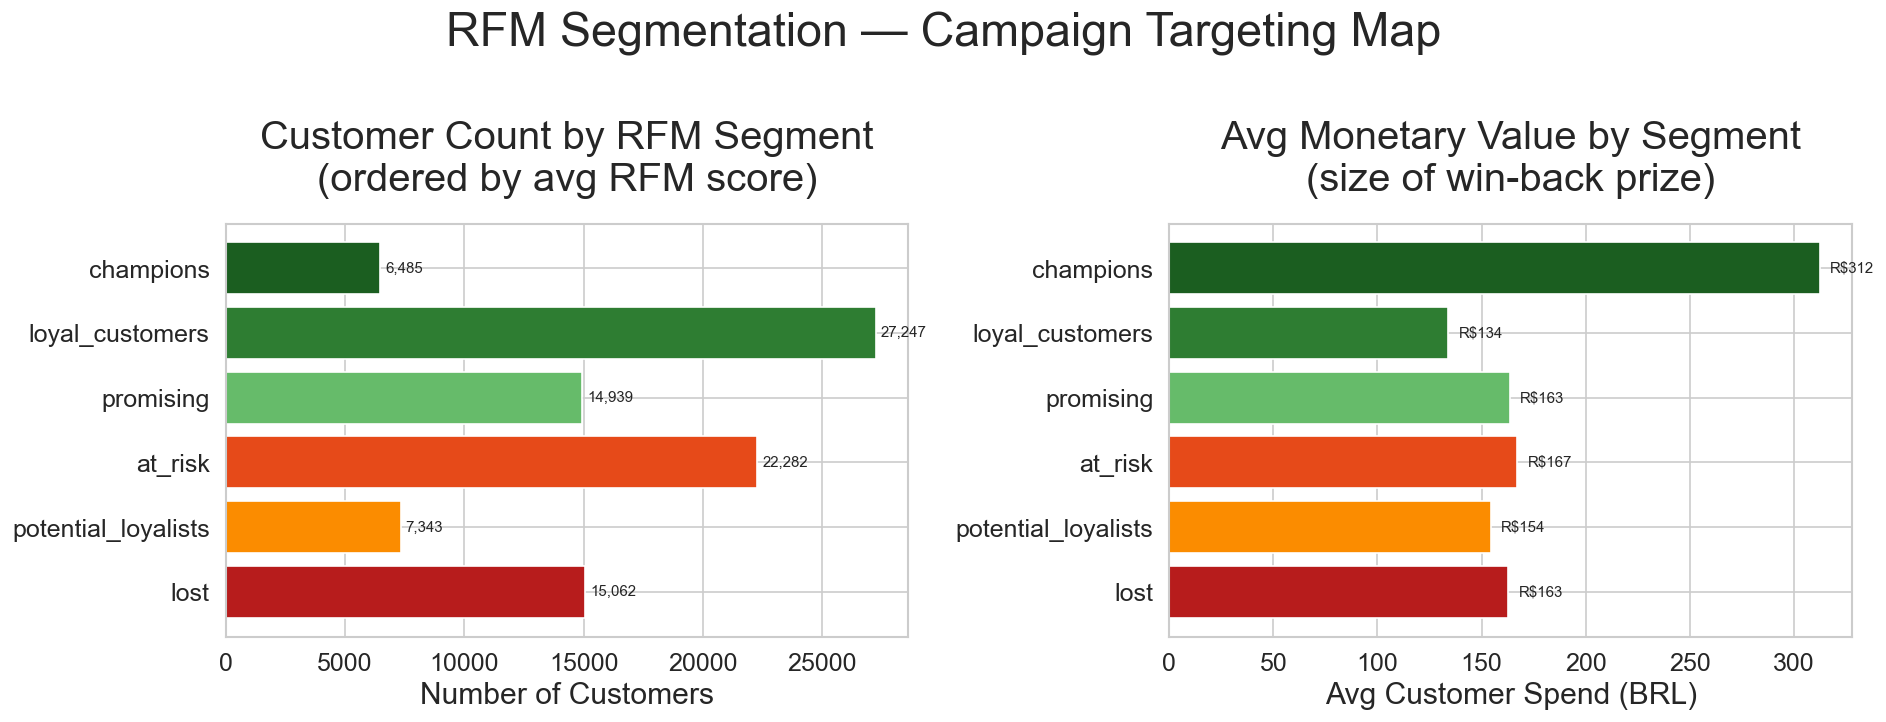


At-risk + lost customers: 37,344 (40.0% of base) — primary win-back campaign targets


In [82]:
SEG_COLORS = {
    "champions":          "#1B5E20",
    "loyal_customers":    "#2E7D32",
    "promising":          "#66BB6A",
    "potential_loyalists":"#FB8C00",
    "at_risk":            "#E64A19",
    "lost":               "#B71C1C",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: customer count per segment
colors = [SEG_COLORS.get(s, "#90A4AE") for s in df_rfm_seg["rfm_segment"]]
bars = axes[0].barh(df_rfm_seg["rfm_segment"], df_rfm_seg["customers"], color=colors)
for bar, n in zip(bars, df_rfm_seg["customers"]):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
                 f"{n:,}", va="center", fontsize=9)
axes[0].set_xlabel("Number of Customers")
axes[0].set_title("Customer Count by RFM Segment\n(ordered by avg RFM score)")
axes[0].invert_yaxis()

# Right: avg monetary value per segment — shows revenue potential
bars2 = axes[1].barh(df_rfm_seg["rfm_segment"], df_rfm_seg["avg_monetary"], color=colors)
for bar, v in zip(bars2, df_rfm_seg["avg_monetary"]):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                 f"R${v:,.0f}", va="center", fontsize=9)
axes[1].set_xlabel("Avg Customer Spend (BRL)")
axes[1].set_title("Avg Monetary Value by Segment\n(size of win-back prize)")
axes[1].invert_yaxis()

plt.suptitle("RFM Segmentation — Campaign Targeting Map", y=1.01)
plt.tight_layout()
plt.show()

actionable = df_rfm_seg[df_rfm_seg["rfm_segment"].isin(["at_risk", "lost"])]
total_actionable = actionable["customers"].sum()
print(f"\nAt-risk + lost customers: {total_actionable:,} "
      f"({total_actionable / df_rfm_seg['customers'].sum() * 100:.1f}% of base) "
      f"— primary win-back campaign targets")

---
## 8. Seller Health Dashboard

**What this tells us:** Each seller receives a composite health score (0–100) based on customer review scores (40%), on-time delivery rate (35%), and overall delivery rate (25%). A 90-day recent window is compared against the all-time baseline to surface trend signals.

**Trend status:**
- `stable` — recent performance in line with historical baseline
- `declining` — recent score dropped >10 points vs baseline (needs intervention)
- `inactive` — no orders in the past 90 days (churn risk or already gone)

**Automation:** `mart_seller_health` recomputes on every daily `dbt run`. Dagster can query `WHERE trend_status != 'stable'` and push alerts to the seller success team before a seller fully churns — closing the visibility gap that currently lets 18% of sellers disappear after a single sale.

In [83]:
df_health = q(f"""
SELECT seller_id, total_orders, health_score, health_tier,
       recent_total_orders, recent_health_score, score_delta, trend_status
FROM `{MARTS}.mart_seller_health`
""")

df_tier = q(f"""
SELECT
    health_tier,
    trend_status,
    COUNT(*)                           AS sellers,
    ROUND(AVG(health_score), 1)        AS avg_score,
    ROUND(AVG(total_orders), 1)        AS avg_orders
FROM `{MARTS}.mart_seller_health`
GROUP BY health_tier, trend_status
ORDER BY avg_score DESC, trend_status
""")
df_tier

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,health_tier,trend_status,sellers,avg_score,avg_orders
0,excellent,inactive,934,93.0,12.1
1,excellent,stable,1575,92.4,52.5
2,excellent,declining,67,87.5,40.1
3,good,stable,113,73.7,12.4
4,good,declining,15,72.8,9.4
5,good,inactive,184,72.3,7.1
6,at_risk,stable,7,51.2,2.1
7,at_risk,inactive,43,50.5,3.2
8,at_risk,declining,2,47.0,7.0
9,critical,declining,1,18.6,2.0


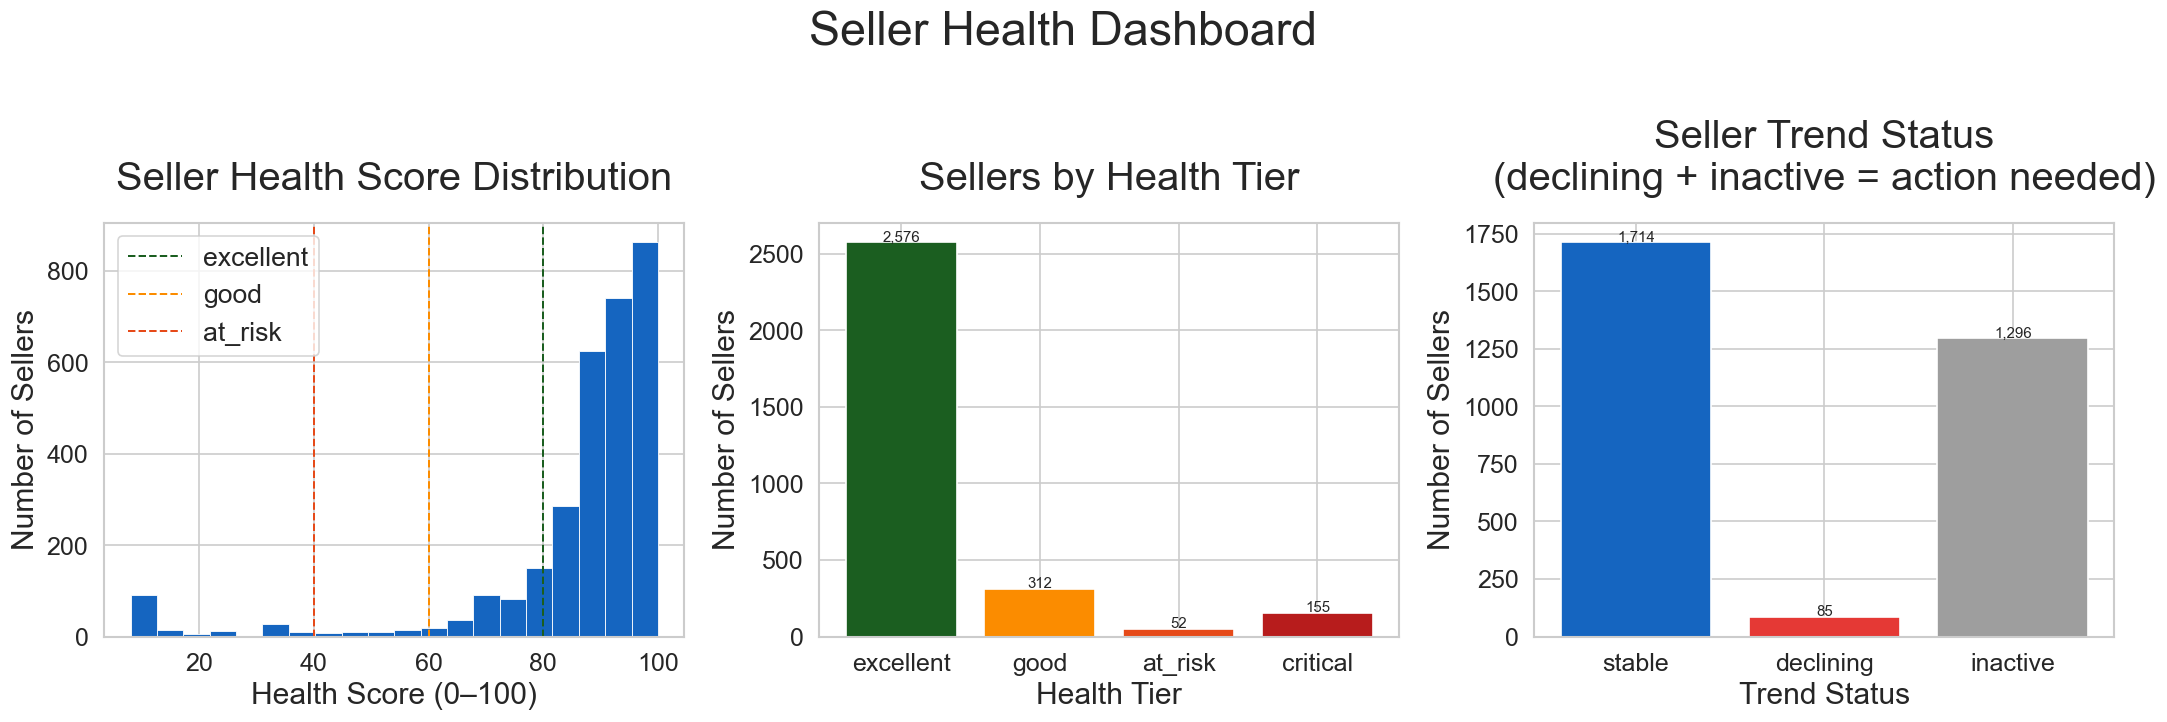


Sellers needing intervention: 1,381 (44.6% of seller base)

Top 10 declining sellers (for outreach):
                       seller_id  health_score  recent_health_score  score_delta  total_orders
9c0e69c7bf2619675bbadf47b43f655a          87.7                  8.0        -79.7           157
80f2cf9abf6b5a0e5c612b5eea6646e6          86.0                  8.0        -78.0             7
2e1a7d075abe038c1b2743005fe42ff1          85.2                  8.0        -77.2            19
cce6ab8d1682639fe45ab70234f1665f          92.8                 16.0        -76.8            63
cd68562d3f44870c08922d380acae552          84.6                  8.0        -76.6           125
725af026f869236a8dd0ceb98564d156          80.3                  8.0        -72.3             7
c4f7fee5b0db50e87766f5a4d1b1b758          73.7                  8.0        -65.7             8
71271995e85f5b8530be99ed54a91b89          67.9                  8.0        -59.9             8
b94cc9f10ddc85e4ba73a6f7974e7101          9

In [84]:
TIER_COLORS = {
    "excellent": "#1B5E20",
    "good":      "#FB8C00",
    "at_risk":   "#E64A19",
    "critical":  "#B71C1C",
}
TREND_COLORS = {
    "stable":   "#1565C0",
    "declining":"#E53935",
    "inactive": "#9E9E9E",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: health score distribution
axes[0].hist(df_health["health_score"].dropna(), bins=20,
             color="#1565C0", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Health Score (0–100)")
axes[0].set_ylabel("Number of Sellers")
axes[0].set_title("Seller Health Score Distribution")
for thresh, label, color in [(80,"excellent","#1B5E20"),(60,"good","#FB8C00"),
                              (40,"at_risk","#E64A19")]:
    axes[0].axvline(thresh, color=color, linestyle="--", linewidth=1.2, label=label)
axes[0].legend()

# Centre: tier breakdown
tier_counts = df_health["health_tier"].value_counts().reindex(
    ["excellent", "good", "at_risk", "critical"]
)
axes[1].bar(tier_counts.index, tier_counts.values,
            color=[TIER_COLORS[t] for t in tier_counts.index])
for i, (tier, cnt) in enumerate(tier_counts.items()):
    axes[1].text(i, cnt + 5, f"{cnt:,}", ha="center", fontsize=9)
axes[1].set_xlabel("Health Tier")
axes[1].set_ylabel("Number of Sellers")
axes[1].set_title("Sellers by Health Tier")

# Right: trend status breakdown
trend_counts = df_health["trend_status"].value_counts().reindex(
    ["stable", "declining", "inactive"]
)
axes[2].bar(trend_counts.index, trend_counts.values,
            color=[TREND_COLORS[t] for t in trend_counts.index])
for i, (trend, cnt) in enumerate(trend_counts.items()):
    axes[2].text(i, cnt + 5, f"{cnt:,}", ha="center", fontsize=9)
axes[2].set_xlabel("Trend Status")
axes[2].set_ylabel("Number of Sellers")
axes[2].set_title("Seller Trend Status\n(declining + inactive = action needed)")

plt.suptitle("Seller Health Dashboard", y=1.01)
plt.tight_layout()
plt.show()

alert_count = (df_health["trend_status"] != "stable").sum()
print(f"\nSellers needing intervention: {alert_count:,} "
      f"({alert_count / len(df_health) * 100:.1f}% of seller base)")
print("\nTop 10 declining sellers (for outreach):")
print(
    df_health[df_health["trend_status"] == "declining"]
    .sort_values("score_delta")
    .head(10)[["seller_id", "health_score", "recent_health_score", "score_delta", "total_orders"]]
    .to_string(index=False)
)